# SAC training

Training and environment parameters are visible in this notebook. Edit its configuration independently of the other algorithms. Run with the project Python environment. Preserved outputs are in `../archive/`; revised cells have cleared outputs. Old models are never loaded automatically.


In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [8]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "rl_project").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import Image, Video, display
from Continuous_Diff_Drive.diff_drive_env import DiffDriveEnv
from Continuous_Diff_Drive.diff_drive_agent import DiffDriveSACAgent
from rl_project.runtime import video_sort_key


## Configuration
Edit the values below for this algorithm. `config.json` is written automatically inside the new run directory as a record of these settings; it is not an input file you need to edit. A later notebook change cannot alter the saved settings of an earlier run.

The environment samples a fixed mixture of obstacle families. The name `curriculum` does not imply increasing difficulty. Normalization is fixed physical scaling; cutoffs retain a bootstrap and carry no extra reward penalty.


In [9]:
ALGORITHM = 'sac'
RUN_TRAINING = False
SEED = 0
NUM_EPISODES = 3000
MAX_ENV_STEPS = None
OUTPUT_ROOT = ROOT / "artifacts"
RECORD_EVERY = 500
LOG_EVERY = 500
WARM_START_CHECKPOINT = None

# Environment settings for this notebook only. Cutoffs are measured in steps.
ENV_KWARGS = {'room_size': (10.0, 10.0),
 'obstacles': None,
 'random_obst': True,
 'robot_start': (1.0, 1.0),
 'goal_pos': (8.5, 8.5),
 'max_step': 1200,
 'n_lidar_rays': 16,
 'lidar_max_range': 5.0,
 'robot_radius': 0.3,
 'dt': 0.1,
 'render_mode': None,
 'obstacle_mode': 'curriculum',
 'obstacle_mix': None}

# Agent settings for this notebook only; no imported training defaults.
AGENT_KWARGS = {'actor_lr': 0.0003,
 'critic_lr': 0.0003,
 'alpha_lr': 0.0003,
 'discount': 0.99,
 'tau': 0.005,
 'alpha': 0.2,
 'batch_size': 256,
 'buffer_size': 100000,
 'hidden_dim': 64,
 'warmup_steps': 5000,
 'updates_per_step': 2,
 'max_grad_norm': 1.0,
 'device': 'cpu',
 'automatic_entropy_tuning': True}


## Train
The saved model and incremental CSV precede optional plotting. A warm start keeps learned network weights but resets replay, optimizers, exploration, temperature and counters. SAC requires a new normalized-input run; the old SAC checkpoint is incompatible.
Every 500 completed episodes, a summary of that block stays above the updating total progress bar. Summaries include mean reward, length, success rate, goal distance, and available losses. The final partial block is also summarized. Summary labels and video filenames start at episode 0; CSV episode numbers and the total bar count completed episodes from 1.


In [10]:
agent = None
result = None
if RUN_TRAINING:
    agent = DiffDriveSACAgent(DiffDriveEnv(**ENV_KWARGS), seed=SEED, **AGENT_KWARGS)
    if WARM_START_CHECKPOINT is not None:
        agent.load_checkpoint(WARM_START_CHECKPOINT, mode="warm_start")
    result = agent.train(NUM_EPISODES, max_env_steps=MAX_ENV_STEPS,
                         output_root=OUTPUT_ROOT, record_every=RECORD_EVERY, log_every=LOG_EVERY)
    print(f"Saved run: {result.run_dir}")
else:
    print("Training not run. Set RUN_TRAINING=True to start a fresh run; no checkpoint was loaded.")


Training not run. Set RUN_TRAINING=True to start a fresh run; no checkpoint was loaded.


## Inspect the new run
Reward bands show rolling mean ± two rolling standard deviations within this run. The outcome plot shows rolling success rate, with SAC temperature when applicable. Final goal distance has a separate square plot spanning 0–10 m and the configured episode budget; faint values show individual episodes and the bold line shows the rolling mean. Values above 10 m are marked at the upper edge. Binary success and collision indicators are omitted.

Videos are separate greedy demonstrations recorded after training episodes 0, 500, 1000, and so on when `RECORD_EVERY=500`. `episode_0.mp4` follows the first training episode, not an untrained policy. Videos are displayed in numerical episode order and are at most 800 pixels wide and 300 frames long.


In [11]:
if result is not None:
    for path in sorted((result.run_dir / "plots").glob("*.png")):
        display(Image(filename=str(path)))
    for path in sorted((result.run_dir / "videos/training").glob("*.mp4"), key=video_sort_key):
        display(Video(filename=str(path), embed=True))


For evaluation, use the corresponding evaluation notebook and select the new checkpoint explicitly, or select the latest completed new run. For five seeds with matched environment-step budgets, use the optional comparison runner described in the section README. No full experiments were rerun as part of the implementation fixes.


File caricato con successo:
c:\Users\39324\Desktop\NAML_RL_gym\artifacts\continuous\sac\20260910T181357962640Z_seed0_88a0e82c\metrics.csv

Colonne trovate nel file CSV:
['episode', 'seed', 'algorithm', 'scenario', 'reward', 'length', 'success', 'collision', 'terminated', 'truncated', 'termination_reason', 'final_distance', 'flags_collected', 'epsilon', 'exploration_mode', 'random_action_steps', 'environment_steps', 'critic_updates', 'actor_updates', 'critic_loss', 'actor_loss', 'alpha_loss', 'alpha', 'td_error']

Colonne identificate:
episode : episode
return  : reward
distance: final_distance
success : success


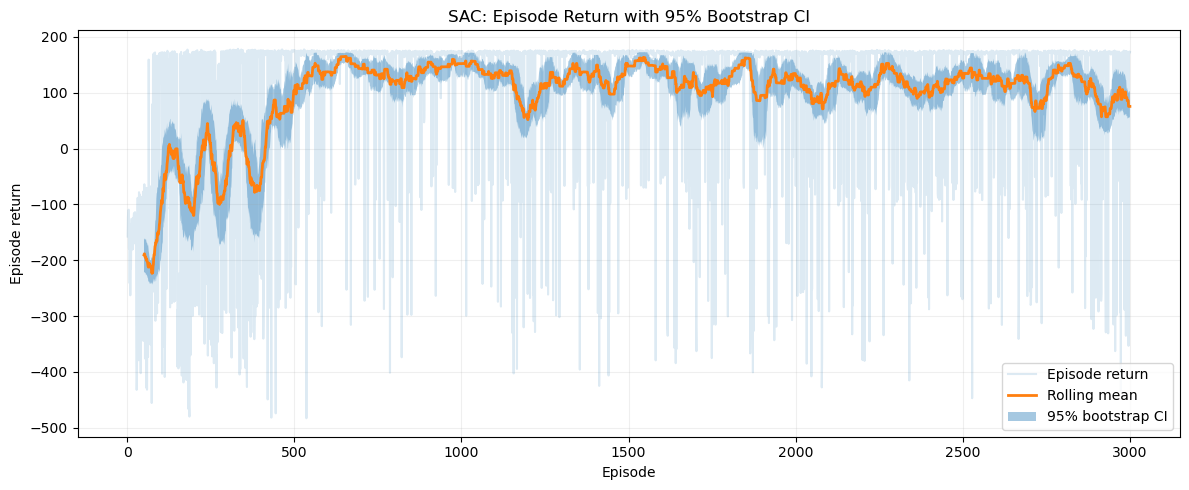

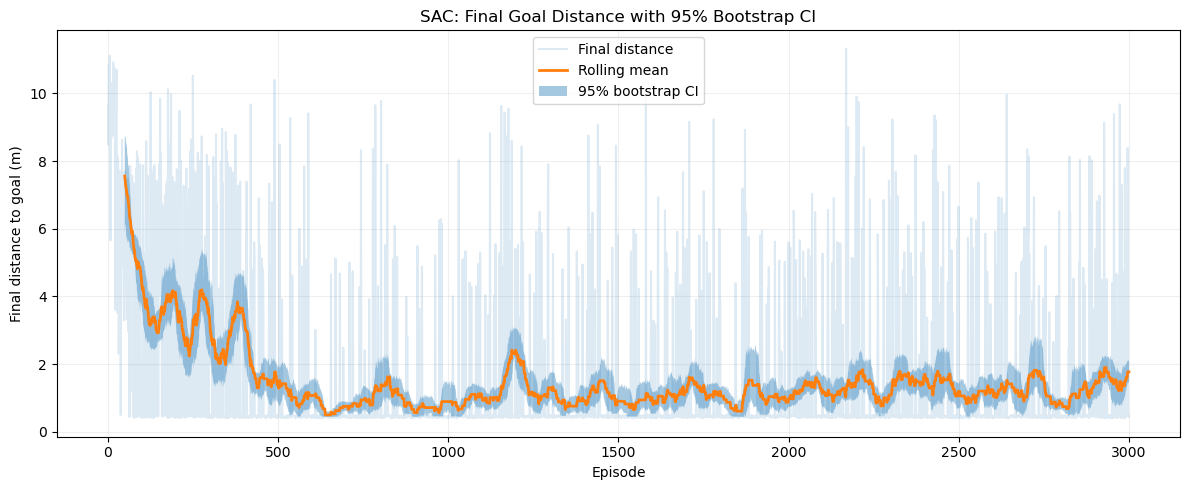

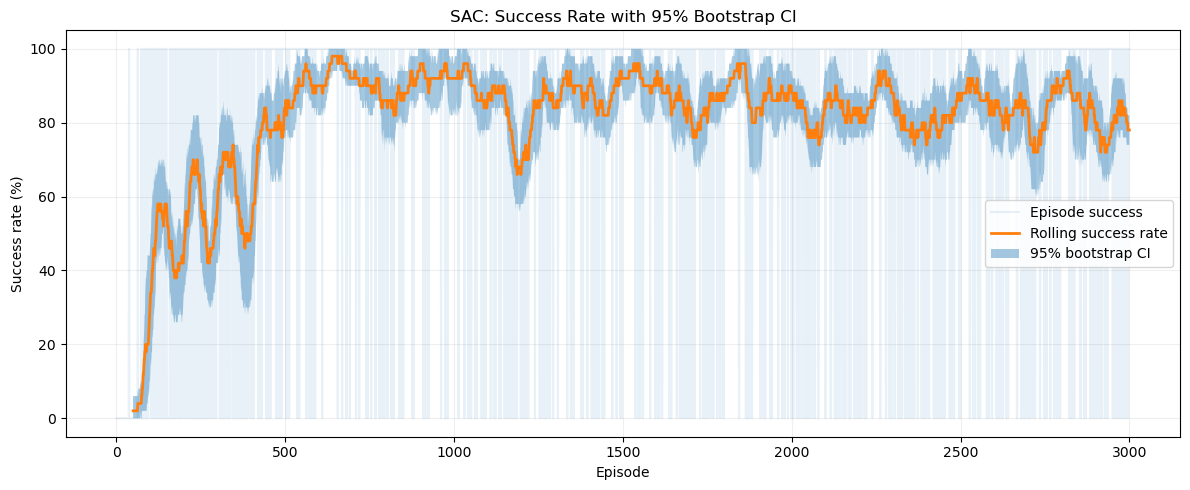

In [12]:
# ============================================================
# Bootstrap confidence intervals for the single DDPG run
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load the metrics CSV
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

csv_path = PROJECT_ROOT / "artifacts" / "continuous" / "sac" / "20260910T181357962640Z_seed0_88a0e82c" / "metrics.csv"

if not csv_path.exists():
  csv_path = PROJECT_ROOT.parent / "artifacts" / "continuous" / "sac" / "20260910T181357962640Z_seed0_88a0e82c" / "metrics.csv"

if not csv_path.exists():
  raise FileNotFoundError(f"File CSV non trovato in: {csv_path}")

df = pd.read_csv(csv_path)

print("\nFile caricato con successo:")
print(csv_path)
print("\nColonne trovate nel file CSV:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 2. Automatically identify the relevant columns
# ------------------------------------------------------------


def find_column(columns, keywords):
  for c in columns:
    cl = c.lower()
    if any(k in cl for k in keywords):
      return c
  return None


episode_col = find_column(df.columns, ["episode"])
return_col = find_column(df.columns, ["episode_return", "return", "reward"])
distance_col = find_column(df.columns, ["final_distance", "goal_distance", "distance"])
success_col = find_column(df.columns, ["success"])

print("\nColonne identificate:")
print("episode :", episode_col)
print("return  :", return_col)
print("distance:", distance_col)
print("success :", success_col)

if episode_col is None or return_col is None:
  raise RuntimeError("Impossibile identificare le colonne episode e return nel CSV. " "Verifica i nomi delle colonne stampati sopra.")


# ------------------------------------------------------------
# 3. Moving-block bootstrap function
# ------------------------------------------------------------


def moving_block_bootstrap_ci(
    values,
    window=100,
    block_size=10,
    n_bootstrap=1000,
    confidence=0.95,
    seed=42
):
    values = np.asarray(values, dtype=float)
    n = len(values)
    
    means = np.full(n, np.nan)
    lower = np.full(n, np.nan)
    upper = np.full(n, np.nan)

    rng = np.random.default_rng(seed)
    alpha = 1.0 - confidence
    n_blocks = int(np.ceil(window / block_size))

    for i in range(window - 1, n):
        x = values[i - window + 1:i + 1]
        x = x[np.isfinite(x)]

        if len(x) < window * 0.8:
            continue

        starts = np.arange(0, len(x) - block_size + 1)
        
        # Genera tutti i campioni bootstrap in una singola matrice 2D (più efficiente)
        sampled_starts = rng.choice(starts, size=(n_bootstrap, n_blocks))
        
        # Estrai i blocchi
        blocks = np.array([x[s:s + block_size] for s in sampled_starts.flat])
        blocks = blocks.reshape(n_bootstrap, n_blocks * block_size)[:, :window]

        # Calcola le medie su ogni riga
        bootstrap_means = np.mean(blocks, axis=1)

        means[i] = np.mean(x)
        lower[i] = np.quantile(bootstrap_means, alpha / 2)
        upper[i] = np.quantile(bootstrap_means, 1 - alpha / 2)

    return means, lower, upper

# ------------------------------------------------------------
# 4. Parameters
# ------------------------------------------------------------

WINDOW = 50
BLOCK_SIZE = 10
N_BOOTSTRAP = 200


# ------------------------------------------------------------
# 5. Plot: Return
# ------------------------------------------------------------

returns = df[return_col].to_numpy(dtype=float)
episodes = df[episode_col].to_numpy()

rolling_return, return_low, return_high = moving_block_bootstrap_ci(
    returns, window=WINDOW, block_size=BLOCK_SIZE, n_bootstrap=N_BOOTSTRAP, seed=42
)

plt.figure(figsize=(12, 5))
plt.plot(episodes, returns, alpha=0.15, label="Episode return")
plt.plot(episodes, rolling_return, linewidth=2, label="Rolling mean")
plt.fill_between(episodes, return_low, return_high, alpha=0.40, label="95% bootstrap CI")
plt.xlabel("Episode")
plt.ylabel("Episode return")
plt.title("SAC: Episode Return with 95% Bootstrap CI")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
plt.close()  # Libera la RAM della figura appena generata

# ------------------------------------------------------------
# 6. Plot: Final goal distance (if column exists)
# ------------------------------------------------------------

if distance_col is not None:
  distances = df[distance_col].to_numpy(dtype=float)

  rolling_dist, dist_low, dist_high = moving_block_bootstrap_ci(
      distances, window=WINDOW, block_size=BLOCK_SIZE, n_bootstrap=N_BOOTSTRAP, seed=42
  )

  plt.figure(figsize=(12, 5))
  plt.plot(episodes, distances, alpha=0.15, label="Final distance")
  plt.plot(episodes, rolling_dist, linewidth=2, label="Rolling mean")
  plt.fill_between(episodes, dist_low, dist_high, alpha=0.40, label="95% bootstrap CI")
  plt.xlabel("Episode")
  plt.ylabel("Final distance to goal (m)")
  plt.title("SAC: Final Goal Distance with 95% Bootstrap CI")
  plt.legend()
  plt.grid(alpha=0.2)
  plt.tight_layout()
  plt.show()
  plt.close()  # Libera la RAM della figura appena generata

# ------------------------------------------------------------
# 7. Plot: Success rate (if column exists)
# ------------------------------------------------------------

if success_col is not None:
  success = df[success_col].to_numpy(dtype=float)

  rolling_success, success_low, success_high = moving_block_bootstrap_ci(
      success, window=WINDOW, block_size=BLOCK_SIZE, n_bootstrap=N_BOOTSTRAP, seed=42
  )

  plt.figure(figsize=(12, 5))
  plt.plot(episodes, success * 100, alpha=0.10, label="Episode success")
  plt.plot(episodes, rolling_success * 100, linewidth=2, label="Rolling success rate")
  plt.fill_between(episodes, success_low * 100, success_high * 100, alpha=0.40, label="95% bootstrap CI")
  plt.xlabel("Episode")
  plt.ylabel("Success rate (%)")
  plt.title("SAC: Success Rate with 95% Bootstrap CI")
  plt.ylim(-5, 105)
  plt.legend()
  plt.grid(alpha=0.2)
  plt.tight_layout()
  plt.show()
  plt.close()  # Libera la RAM della figura appena generata

File caricato con successo:
c:\Users\39324\Desktop\NAML_RL_gym\artifacts\continuous\sac\20260910T181357962640Z_seed0_88a0e82c\metrics.csv

Colonne trovate nel file CSV:
['episode', 'seed', 'algorithm', 'scenario', 'reward', 'length', 'success', 'collision', 'terminated', 'truncated', 'termination_reason', 'final_distance', 'flags_collected', 'epsilon', 'exploration_mode', 'random_action_steps', 'environment_steps', 'critic_updates', 'actor_updates', 'critic_loss', 'actor_loss', 'alpha_loss', 'alpha', 'td_error']

Colonne identificate:
episode     : episode
return      : reward
length      : length
critic_loss : critic_loss
actor_loss  : actor_loss


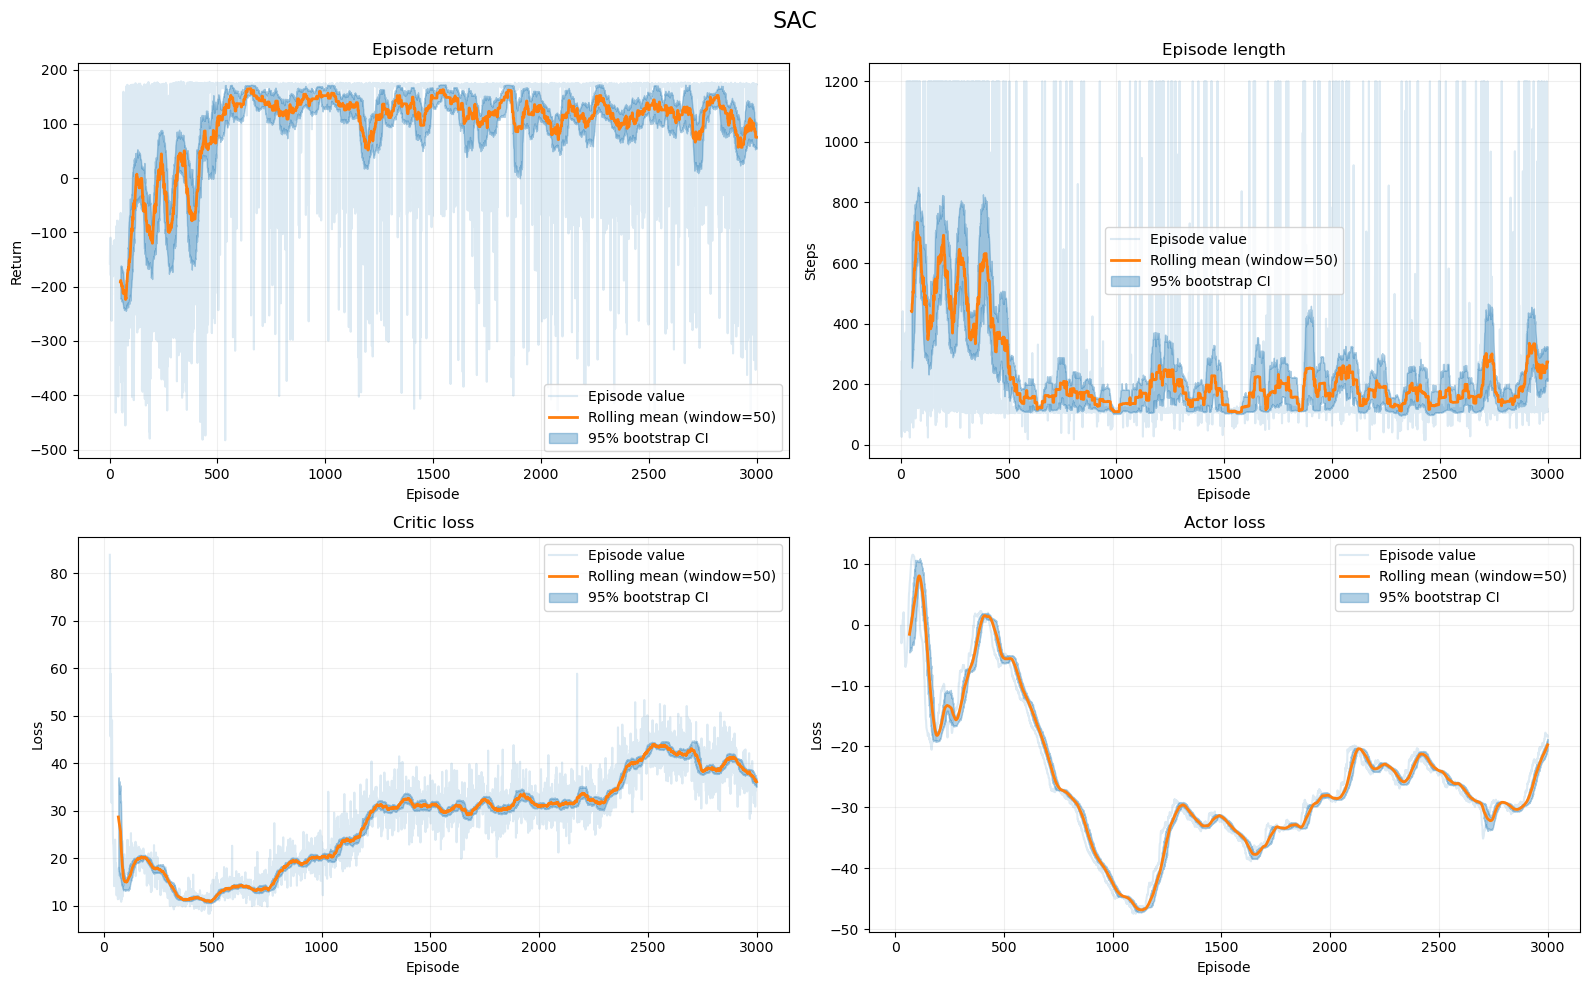


Salvato: sac_training_curves_bootstrap.png


In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load the metrics CSV
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

csv_path = PROJECT_ROOT / "artifacts" / "continuous" / "sac" / "20260910T181357962640Z_seed0_88a0e82c" / "metrics.csv"

if not csv_path.exists():
    csv_path = PROJECT_ROOT.parent / "artifacts" / "continuous" / "sac" / "20260910T181357962640Z_seed0_88a0e82c" / "metrics.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"File CSV non trovato in: {csv_path}")

df = pd.read_csv(csv_path)

print("File caricato con successo:")
print(csv_path)
print("\nColonne trovate nel file CSV:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 2. Automatically identify the relevant columns
# ------------------------------------------------------------

def find_column(columns, keywords):
    for c in columns:
        cl = c.lower()
        if any(k in cl for k in keywords):
            return c
    return None


episode_col = find_column(df.columns, ["episode"])
return_col = find_column(df.columns, ["episode_return", "return", "reward"])
length_col = find_column(df.columns, ["episode_length", "length", "steps"])
critic_loss_col = find_column(df.columns, ["critic_loss", "loss_critic"])
actor_loss_col = find_column(df.columns, ["actor_loss", "loss_actor"])

print("\nColonne identificate:")
print("episode     :", episode_col)
print("return      :", return_col)
print("length      :", length_col)
print("critic_loss :", critic_loss_col)
print("actor_loss  :", actor_loss_col)

if episode_col is None or return_col is None:
    raise RuntimeError(
        "Impossibile identificare le colonne episode e return nel CSV. "
        "Verifica i nomi delle colonne stampati sopra."
    )

episodes = df[episode_col].to_numpy()


# ------------------------------------------------------------
# 3. Moving-block bootstrap function (identica a quella del notebook)
# ------------------------------------------------------------

def moving_block_bootstrap_ci(
    values,
    window=100,
    block_size=10,
    n_bootstrap=1000,
    confidence=0.95,
    seed=42
):
    values = np.asarray(values, dtype=float)
    n = len(values)

    means = np.full(n, np.nan)
    lower = np.full(n, np.nan)
    upper = np.full(n, np.nan)

    rng = np.random.default_rng(seed)
    alpha = 1.0 - confidence
    n_blocks = int(np.ceil(window / block_size))

    for i in range(window - 1, n):
        x = values[i - window + 1:i + 1]
        x = x[np.isfinite(x)]

        if len(x) < window * 0.8:
            continue

        starts = np.arange(0, len(x) - block_size + 1)

        sampled_starts = rng.choice(starts, size=(n_bootstrap, n_blocks))
        blocks = np.array([x[s:s + block_size] for s in sampled_starts.flat])
        blocks = blocks.reshape(n_bootstrap, n_blocks * block_size)[:, :window]

        bootstrap_means = np.mean(blocks, axis=1)

        means[i] = np.mean(x)
        lower[i] = np.quantile(bootstrap_means, alpha / 2)
        upper[i] = np.quantile(bootstrap_means, 1 - alpha / 2)

    return means, lower, upper


# ------------------------------------------------------------
# 4. Parameters (stessi usati per la curva di return bootstrap)
# ------------------------------------------------------------

WINDOW = 50
BLOCK_SIZE = 10
N_BOOTSTRAP = 200


def plot_panel(ax, values, title, ylabel, raw_alpha=0.15):
    rolling, low, high = moving_block_bootstrap_ci(
        values, window=WINDOW, block_size=BLOCK_SIZE,
        n_bootstrap=N_BOOTSTRAP, seed=42
    )
    ax.plot(episodes, values, alpha=raw_alpha, color="tab:blue", label="Episode value")
    ax.plot(episodes, rolling, linewidth=2, color="tab:orange",
             label=f"Rolling mean (window={WINDOW})")
    ax.fill_between(episodes, low, high, alpha=0.35, color="tab:blue",
                     label="95% bootstrap CI")
    ax.set_title(title)
    ax.set_xlabel("Episode")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.2)


# ------------------------------------------------------------
# 5. Build the 4-panel figure
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("SAC", fontsize=16)

plot_panel(axes[0, 0], df[return_col].to_numpy(dtype=float),
           "Episode return", "Return")

if length_col is not None:
    plot_panel(axes[0, 1], df[length_col].to_numpy(dtype=float),
               "Episode length", "Steps")
else:
    axes[0, 1].axis("off")
    axes[0, 1].set_title("Episode length: colonna non trovata nel CSV")

if critic_loss_col is not None:
    plot_panel(axes[1, 0], df[critic_loss_col].to_numpy(dtype=float),
               "Critic loss", "Loss")
else:
    axes[1, 0].axis("off")
    axes[1, 0].set_title("Critic loss: colonna non trovata nel CSV")

if actor_loss_col is not None:
    plot_panel(axes[1, 1], df[actor_loss_col].to_numpy(dtype=float),
               "Actor loss", "Loss")
else:
    axes[1, 1].axis("off")
    axes[1, 1].set_title("Actor loss: colonna non trovata nel CSV")

plt.tight_layout()
plt.savefig("sac_training_curves_bootstrap.png", dpi=150)
plt.show()
plt.close()

print("\nSalvato: sac_training_curves_bootstrap.png")
